# 1: Importação e Preparação dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Carregar os dados limpos
df = pd.read_pickle('dados_voos_limpos.pkl')

# 2. Criar métricas por aeroporto de origem
aeroportos_stats = df.groupby('ORIGIN_AIRPORT').agg({
    'SCHEDULED_DEPARTURE': 'count', # Volume de voos
    'ARRIVAL_DELAY': 'mean',        # Média de atraso
    'IS_DELAYED': 'mean'            # Taxa de atraso (0 a 1)
}).rename(columns={'SCHEDULED_DEPARTURE': 'TOTAL_VOOS', 'IS_DELAYED': 'TAXA_ATRASO'})

# Filtrar aeroportos com pouquíssimos voos para não gerar ruído (outliers)
aeroportos_stats = aeroportos_stats[aeroportos_stats['TOTAL_VOOS'] > 100]

print(f"Analisando {len(aeroportos_stats)} aeroportos.")

Analisando 533 aeroportos.


# 2: O Método do Cotovelo (Elbow Method)

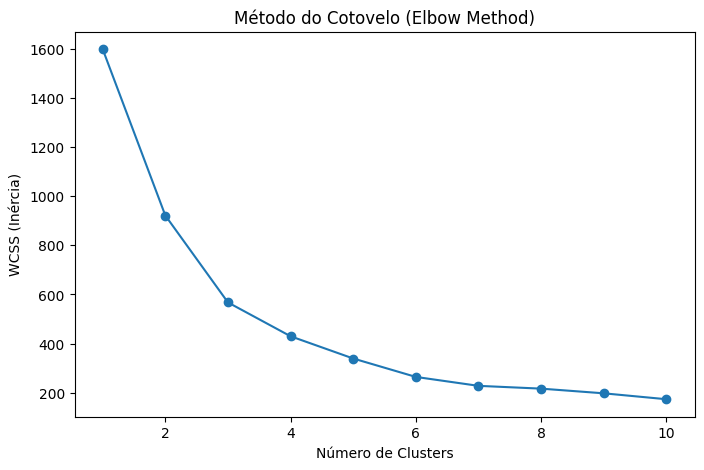

In [2]:
# Normalizar os dados (essencial para K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(aeroportos_stats)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS (Inércia)')
plt.show()

# 3: Executando o K-Means

In [5]:
# Aplicando o K-Means com 3 clusters
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)

# O segredo está aqui: usamos .fit() primeiro
kmeans.fit(X_scaled)

# E depois pegamos apenas os labels (os números 0, 1 e 2)
aeroportos_stats['CLUSTER'] = kmeans.labels_

# Vamos ver a média de cada grupo para entender o perfil deles
resumo_clusters = aeroportos_stats.groupby('CLUSTER').mean()
print(resumo_clusters)

            TOTAL_VOOS  ARRIVAL_DELAY  TAXA_ATRASO
CLUSTER                                           
0          7400.473077       5.805868     0.177504
1          3147.559524      -1.336494     0.104989
2        142432.428571       5.163482     0.194954


# 4: Visualização e Interpretação

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=aeroportos_stats, x='TOTAL_VOOS', y='TAXA_ATRASO', 
                hue='CLUSTER', palette='viridis', s=100)
plt.title('Agrupamento de Aeroportos por Volume e Taxa de Atraso')
plt.xlabel('Total de Voos no Período')
plt.ylabel('Taxa de Atrasos (>15 min)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()